In [36]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 2.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 2.3 MB/s eta 0:00:0000:0100:01


In [121]:
!pip install seaborn

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm
import pickle

In [80]:
# df_p = pd.read_csv("bisg_done_sample_fl_nyc.csv")
df_p = pd.read_csv("bisg_done_sample_fl_nyc-second-run.csv")

/var/folders/p6/q5_ltxc53ws4lf3s9mr35j400000gn/T/ipykernel_4780/1838006878.py:2: DtypeWarning: Columns (12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p = pd.read_csv("bisg_done_sample_fl_nyc-second-run.csv")


In [81]:
keys1 = ['W', 'B', 'A', 'HL']
#values1 = [0.66, 0.3, 0.5, 0.5]
values1 = [0.62, 0.5, 0.5, 0.54]

py_race_cutoffs = dict(zip(keys1, values1))

In [82]:
df_p['predicted_race'] = 'U'

df_p.loc[df_p['prob_white'] >= py_race_cutoffs['W'], 'predicted_race'] = 'W'
df_p.loc[df_p['prob_black'] >= py_race_cutoffs['B'], 'predicted_race'] = 'B'
df_p.loc[df_p['prob_asian'] >= py_race_cutoffs['A'], 'predicted_race'] = 'A'
df_p.loc[df_p['prob_hisp'] >= py_race_cutoffs['HL'], 'predicted_race'] = 'HL'

In [83]:
df_p.to_csv("NYC_Payroll_With_Race_complete.csv")

In [84]:
race_counts = df_p['predicted_race'].value_counts().reset_index()
race_counts.columns = ['race', 'count']
print(race_counts)

  race   count
0    W  210419
1   HL  131560
2    B  118048
3    A   56796
4    U   45645


In [85]:
df_p["base_salary"] = (
    df_p["base_salary"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .apply(pd.to_numeric, errors="coerce")
)

In [86]:
#INITIAL - DO NOT RUN
salary_stats = df_p.groupby("predicted_race")["base_salary"].agg(["min","max"]).reset_index()
print(salary_stats)

  predicted_race  min       max
0              A  1.0  287663.0
1              B  0.5  313941.0
2             HL  1.0  287663.0
3              U  1.0  414799.0
4              W  1.0  393532.0


In [87]:
salary_stats = df_p.groupby("predicted_race")["base_salary"].agg(["min","max"]).reset_index()
print(salary_stats)

  predicted_race  min       max
0              A  1.0  287663.0
1              B  0.5  313941.0
2             HL  1.0  287663.0
3              U  1.0  414799.0
4              W  1.0  393532.0


In [88]:
df = df_p.copy()

In [89]:
# ---------------------------
# 1. Convert salary + payment fields to float
# ---------------------------
num_cols = ["base_salary","regular_gross_paid","ot_hours","total_ot_paid","total_other_pay","regular_hours"]

for col in num_cols:
    df[col] = (df[col].astype(str)
                      .str.replace("$","",regex=False)
                      .str.replace(",","",regex=False)
                      .astype(float))

In [90]:
# ---------------------------
# 2. Convert date → numeric tenure feature
# ---------------------------
df["agency_start_date"] = pd.to_datetime(df["agency_start_date"], errors="coerce")
df["years_with_agency"] = (pd.Timestamp.today() - df["agency_start_date"]).dt.days / 365
df.drop(columns=["agency_start_date"], inplace=True)  # optional to drop raw date

In [91]:
# ---------------------------
# 3. Encode categorical columns
# ---------------------------
label_cols = ["agency_name", "work_location_borough", "title_description",
              "pay_basis", "leave_status_as_of_june_30", "predicted_race"]

# for col in label_cols:
#     df[col] = LabelEncoder().fit_transform(df[col].astype(str))
encoders = {}  # store mapping for later

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [92]:
encoders["predicted_race"].classes_

array(['A', 'B', 'HL', 'U', 'W'], dtype=object)

In [93]:
df.head(1)
len(df.columns)

22

In [94]:

# scale_cols = ["regular_hours","regular_gross_paid","ot_hours",
#               "total_ot_paid","total_other_pay","years_with_agency"]

# df[scale_cols] = StandardScaler().fit_transform(df[scale_cols])

In [95]:
df = df.drop(columns=['first_name', 'last_name', 'prob_asian', 'prob_white', 'prob_hisp', 'prob_black'])

In [96]:
feature_cols = ['fiscal_year', 'agency_name', 'work_location_borough', 
                'title_description', 'leave_status_as_of_june_30', 
                'pay_basis', 'regular_hours', 'regular_gross_paid', 
                'ot_hours', 'total_ot_paid', 'total_other_pay', 'predicted_race']

X = df[feature_cols]
y = df['base_salary']

In [97]:
categorical_features = ['agency_name', 'work_location_borough', 'title_description',
                        'leave_status_as_of_june_30', 'pay_basis', 'predicted_race']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # numeric columns are kept as-is
)

X_processed = preprocessor.fit_transform(X)

In [98]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['cat__agency_name_0' 'cat__agency_name_1' 'cat__agency_name_2' ...
 'remainder__ot_hours' 'remainder__total_ot_paid'
 'remainder__total_other_pay']


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42)

In [100]:
model = RandomForestRegressor(n_estimators=2, random_state=42, verbose = 2)
model.fit(X_train, y_train)

building tree 1 of 2
building tree 2 of 2


RandomForestRegressor(n_estimators=2, random_state=42, verbose=2)

In [101]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [102]:
# y_pred = model.predict(X_test)

y_pred = np.array(
    [model.predict(X_test[i : i + 1])[0] for i in tqdm(range(X_test.shape[0]))]
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 112494/112494 [01:06<00:00, 1694.48it/s]

MAE: 1722.6998370301642
MSE: 38135309.00692083
R2: 0.9855044201426005


In [107]:
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test
onehot_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
numeric_cols = [col for col in X.columns if col not in categorical_features]
all_cols = list(onehot_cols) + numeric_cols

X_test_df = pd.DataFrame(X_test_dense, columns=all_cols)
# X_test_df = pd.DataFrame(X_test, columns=feature_names)

results = pd.DataFrame({
    "actual_salary": y_test,
    "predicted_salary": y_pred
})

final_export = pd.concat([X_test_df.reset_index(drop=True),
                          results.reset_index(drop=True)], axis=1)


In [108]:
race_cols = ['predicted_race_0', 'predicted_race_1', 'predicted_race_2',
             'predicted_race_3', 'predicted_race_4']

id_to_race = {0:"A", 1:"B", 2:"HL", 3:"U", 4:"W"}

race_index = final_export[race_cols].idxmax(axis=1)  # gives column name like 'predicted_race_2'

# Step 2 — extract the numeric index from the column name
race_numeric = race_index.str.extract(r'(\d+)').astype(int)

# Step 3 — map number → race category using dictionary
final_export["predicted_race"] = race_numeric[0].map(id_to_race)

# (Optional) Drop the one-hot race columns
final_export.drop(columns=race_cols, inplace=True)

In [109]:
final_export.to_csv("model_salary_predictions.csv", index=False)

In [112]:
final_export.groupby("predicted_race")["predicted_salary"].mean()


predicted_race
A     53765.582716
B     48709.020088
HL    50294.113431
U     53666.593227
W     61395.936790
Name: predicted_salary, dtype: float64

In [114]:
final_export.groupby("predicted_race")[["actual_salary", "predicted_salary"]].mean()

,actual_salary,predicted_salary
predicted_race,,
A,53811.807196,53765.582716
B,48739.757123,48709.020088
HL,50298.322840,50294.113431
U,53709.909120,53666.593227
W,61594.120921,61395.936790


In [116]:
final_export.groupby("predicted_race")["predicted_salary"].mean() / final_export["predicted_salary"].mean()

predicted_race
A     0.982233
B     0.889856
HL    0.918813
U     0.980424
W     1.121630
Name: predicted_salary, dtype: float64

In [119]:
final_export["residual"] = final_export["predicted_salary"] - final_export["actual_salary"]
final_export.groupby("predicted_race")["residual"].mean()

predicted_race
A     -46.224480
B     -30.737035
HL     -4.209409
U     -43.315894
W    -198.184131
Name: residual, dtype: float64

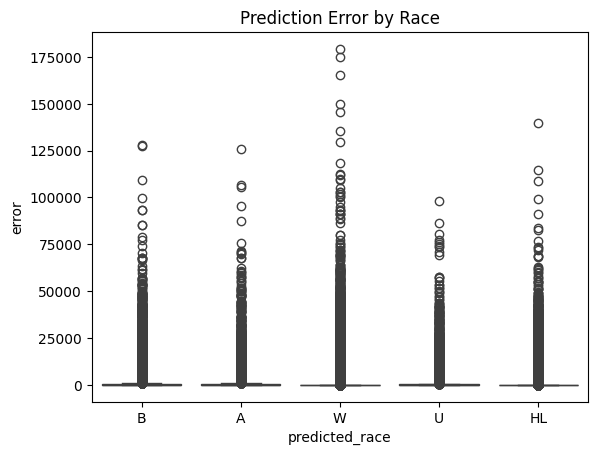

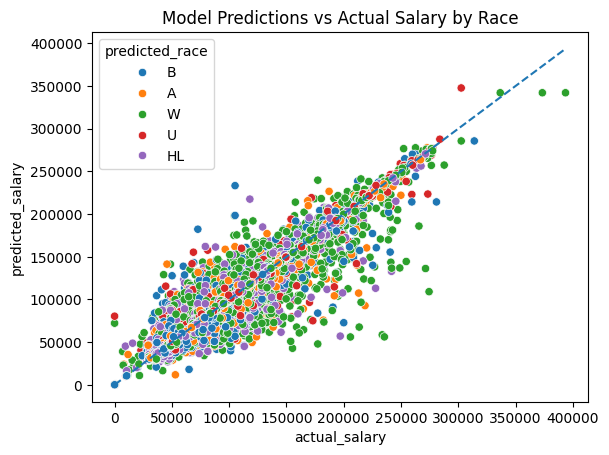

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

final_export["error"] = np.abs(final_export["actual_salary"] - final_export["predicted_salary"])
# df.groupby("predicted)race")["error"].mean()

sns.boxplot(data=final_export, x="predicted_race", y="error")
plt.title("Prediction Error by Race")
plt.show()
sns.scatterplot(data=final_export, x="actual_salary", y="predicted_salary", hue="predicted_race")
plt.plot([final_export.actual_salary.min(), final_export.actual_salary.max()],
         [final_export.actual_salary.min(), final_export.actual_salary.max()], linestyle="--")
plt.title("Model Predictions vs Actual Salary by Race")
plt.show()

In [ ]:
# model = RandomForestRegressor(n_estimators=100, random_state=42, n_estimators=500, verbose=2)
# model.fit(X_train, y_train)


# import pickle

# with open("model.pkl", "wb") as f:
#     pickle.dump(model, f)

# with open("model.pkl", "rb") as f:
#     model = pickle.load(f)

# y_pred = np.array([ model.predict(X_test[i:i+1])[0] for i in tqdm(range(len(X_test))) ])

# y_pred = np.array([
#     model.predict(X_test[i:i+1])[0] 
#     for i in tqdm(range(X_test.shape[0]))
# ])

In [110]:
# preprocessor.named_transformers_['cat'].categories_

In [ ]:
# race_cols = ['predicted_race_0', 'predicted_race_1', 'predicted_race_2',
#              'predicted_race_3', 'predicted_race_4']

# id_to_race = {0:"B", 1:"A", 2:"HL", 3:"W", 4:"U"}

# df["predicted_race_label"] = (
#     df[race_cols].idxmax(axis=1)        # returns "predicted_race_X"
#     .str[-1].astype(int)                # get number X
#     .map(id_to_race)                    # convert to race letter
# )

In [ ]:
# predicted_df = pd.read_csv("salary_predictions.csv")